In [1]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

In [2]:
df = pd.read_csv('data/food_delivery_orders_dataset.csv')
df.shape

(50000, 37)

In [3]:
df.head()

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9


In [4]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'driver_id',
       'order_timestamp', 'order_date', 'order_hour', 'day_of_week',
       'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type',
       'restaurant_type', 'restaurant_primary_category', 'restaurant_rating',
       'items_count', 'subtotal', 'discount_percent', 'tax_amount',
       'service_fee', 'delivery_fee', 'order_total', 'payment_method',
       'tip_amount', 'distance_km', 'weather', 'traffic_level',
       'delivery_partner_experience_months', 'delivery_partner_rating',
       'restaurant_preparation_time_minutes',
       'estimated_delivery_time_minutes', 'actual_delivery_time_minutes',
       'late_delivery', 'order_status', 'cancellation_reason',
       'customer_rating'],
      dtype='str')

In [5]:
df.drop(['late_delivery', 'order_status', 'estimated_delivery_time_minutes'], axis=1, inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   order_id                             50000 non-null  str    
 1   customer_id                          50000 non-null  str    
 2   restaurant_id                        50000 non-null  str    
 3   driver_id                            50000 non-null  str    
 4   order_timestamp                      50000 non-null  str    
 5   order_date                           50000 non-null  str    
 6   order_hour                           50000 non-null  int64  
 7   day_of_week                          50000 non-null  str    
 8   is_weekend                           50000 non-null  int64  
 9   city                                 50000 non-null  str    
 10  delivery_area                        50000 non-null  str    
 11  customer_age                         50

#### To Avoid Data Leakage and influence of Train Data on Test Data performing train_test_split at the initial stage

In [7]:
X = df.drop('actual_delivery_time_minutes', axis=1)
y = df['actual_delivery_time_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [8]:
df_train = pd.concat([X_train, y_train], axis='columns')
df_test = pd.concat([X_test, y_test], axis='columns')

print("Shape of Training Data: ", df_train.shape)
print("Shape of Test Data: ", df_test.shape)

Shape of Training Data:  (37500, 34)
Shape of Test Data:  (12500, 34)


In [9]:
df_train.head()

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,tip_amount,distance_km,weather,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,cancellation_reason,customer_rating,actual_delivery_time_minutes
27434,ORD_027435,CUS_00008,RES_0016,DRV_0032,2025-10-13 08:13:00,2025-10-13,8,Monday,0,City_A,...,7.60,4.5,Rain,Medium,6,4.9,29,NaN,4.2,47.0
13400,ORD_013401,CUS_00043,RES_0001,DRV_0188,2025-10-07 20:07:00,2025-10-07,20,Tuesday,0,City_A,...,3.65,3.5,Clear,High,31,4.5,10,NaN,4.0,29.0
883,ORD_000884,CUS_00025,RES_0059,DRV_0003,2025-10-10 21:09:00,2025-10-10,21,Friday,0,City_A,...,5.57,9.5,Clear,Medium,48,4.8,21,NaN,4.9,57.0
7303,ORD_007304,CUS_00035,RES_0009,DRV_0027,2025-10-15 18:12:00,2025-10-15,18,Wednesday,0,City_B,...,0.00,2.1,Rain,Medium,33,4.5,28,NaN,3.9,36.0
45124,ORD_045125,CUS_00002,RES_0003,DRV_0006,2025-10-02 17:50:00,2025-10-02,17,Thursday,0,City_C,...,0.00,8.6,Cloudy,Low,57,4.9,11,NaN,3.8,40.0


#### Data Preparation and Exploratory Analysis

Hanlding NA and Duplicated Values and Data Cleaning

In [10]:
df_train.isna().sum()

order_id                                   0
customer_id                                0
restaurant_id                              0
driver_id                                  0
order_timestamp                            0
order_date                                 0
order_hour                                 0
day_of_week                                0
is_weekend                                 0
city                                       0
delivery_area                              0
customer_age                               0
customer_type                              0
restaurant_type                            0
restaurant_primary_category                0
restaurant_rating                          0
items_count                                0
subtotal                                   0
discount_percent                           0
tax_amount                                 0
service_fee                                0
delivery_fee                               0
order_tota

In [11]:
"""
Since, tip_amount, cancellation_reason, customer_rating are the fields which does not contribute in predicting the 
estimated delivery time as they are measured post order completion so removing them now.
"""

df_train.drop(['tip_amount', 'cancellation_reason', 'customer_rating'], axis=1, inplace=True)
df_test.drop(['tip_amount', 'cancellation_reason', 'customer_rating'], axis=1, inplace=True)

In [12]:
df_train.dropna(subset=['actual_delivery_time_minutes'], inplace=True)
df_test.dropna(subset=['actual_delivery_time_minutes'], inplace=True)

print("Shape of Training Data after dropping nulls: ", df_train.shape)
print("Shape of Test Data after dropping nulls: ", df_test.shape)

Shape of Training Data after dropping nulls:  (36862, 31)
Shape of Test Data after dropping nulls:  (12270, 31)


In [13]:
df_train['actual_delivery_time_minutes'].isna().sum()

np.int64(0)

In [14]:
df_test['actual_delivery_time_minutes'].isna().sum()

np.int64(0)

In [15]:
df_train.isna().sum()

order_id                               0
customer_id                            0
restaurant_id                          0
driver_id                              0
order_timestamp                        0
order_date                             0
order_hour                             0
day_of_week                            0
is_weekend                             0
city                                   0
delivery_area                          0
customer_age                           0
customer_type                          0
restaurant_type                        0
restaurant_primary_category            0
restaurant_rating                      0
items_count                            0
subtotal                               0
discount_percent                       0
tax_amount                             0
service_fee                            0
delivery_fee                           0
order_total                            0
payment_method                         0
distance_km     

In [16]:
df_train.duplicated().sum()

np.int64(0)

In [17]:
df_train.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'driver_id',
       'order_timestamp', 'order_date', 'order_hour', 'day_of_week',
       'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type',
       'restaurant_type', 'restaurant_primary_category', 'restaurant_rating',
       'items_count', 'subtotal', 'discount_percent', 'tax_amount',
       'service_fee', 'delivery_fee', 'order_total', 'payment_method',
       'distance_km', 'weather', 'traffic_level',
       'delivery_partner_experience_months', 'delivery_partner_rating',
       'restaurant_preparation_time_minutes', 'actual_delivery_time_minutes'],
      dtype='str')

In [18]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

Index(['order_hour', 'is_weekend', 'customer_age', 'restaurant_rating',
       'items_count', 'subtotal', 'discount_percent', 'tax_amount',
       'service_fee', 'delivery_fee', 'order_total', 'distance_km',
       'delivery_partner_experience_months', 'delivery_partner_rating',
       'restaurant_preparation_time_minutes', 'actual_delivery_time_minutes'],
      dtype='str')

In [19]:
categorical_cols = df_train.select_dtypes(include='str').columns
categorical_cols = ['day_of_week', 'city', 'delivery_area',
       'customer_type', 'restaurant_type', 'restaurant_primary_category',
       'payment_method', 'weather', 'traffic_level']
categorical_cols

['day_of_week',
 'city',
 'delivery_area',
 'customer_type',
 'restaurant_type',
 'restaurant_primary_category',
 'payment_method',
 'weather',
 'traffic_level']

Univariate Analysis on Numerical Columns

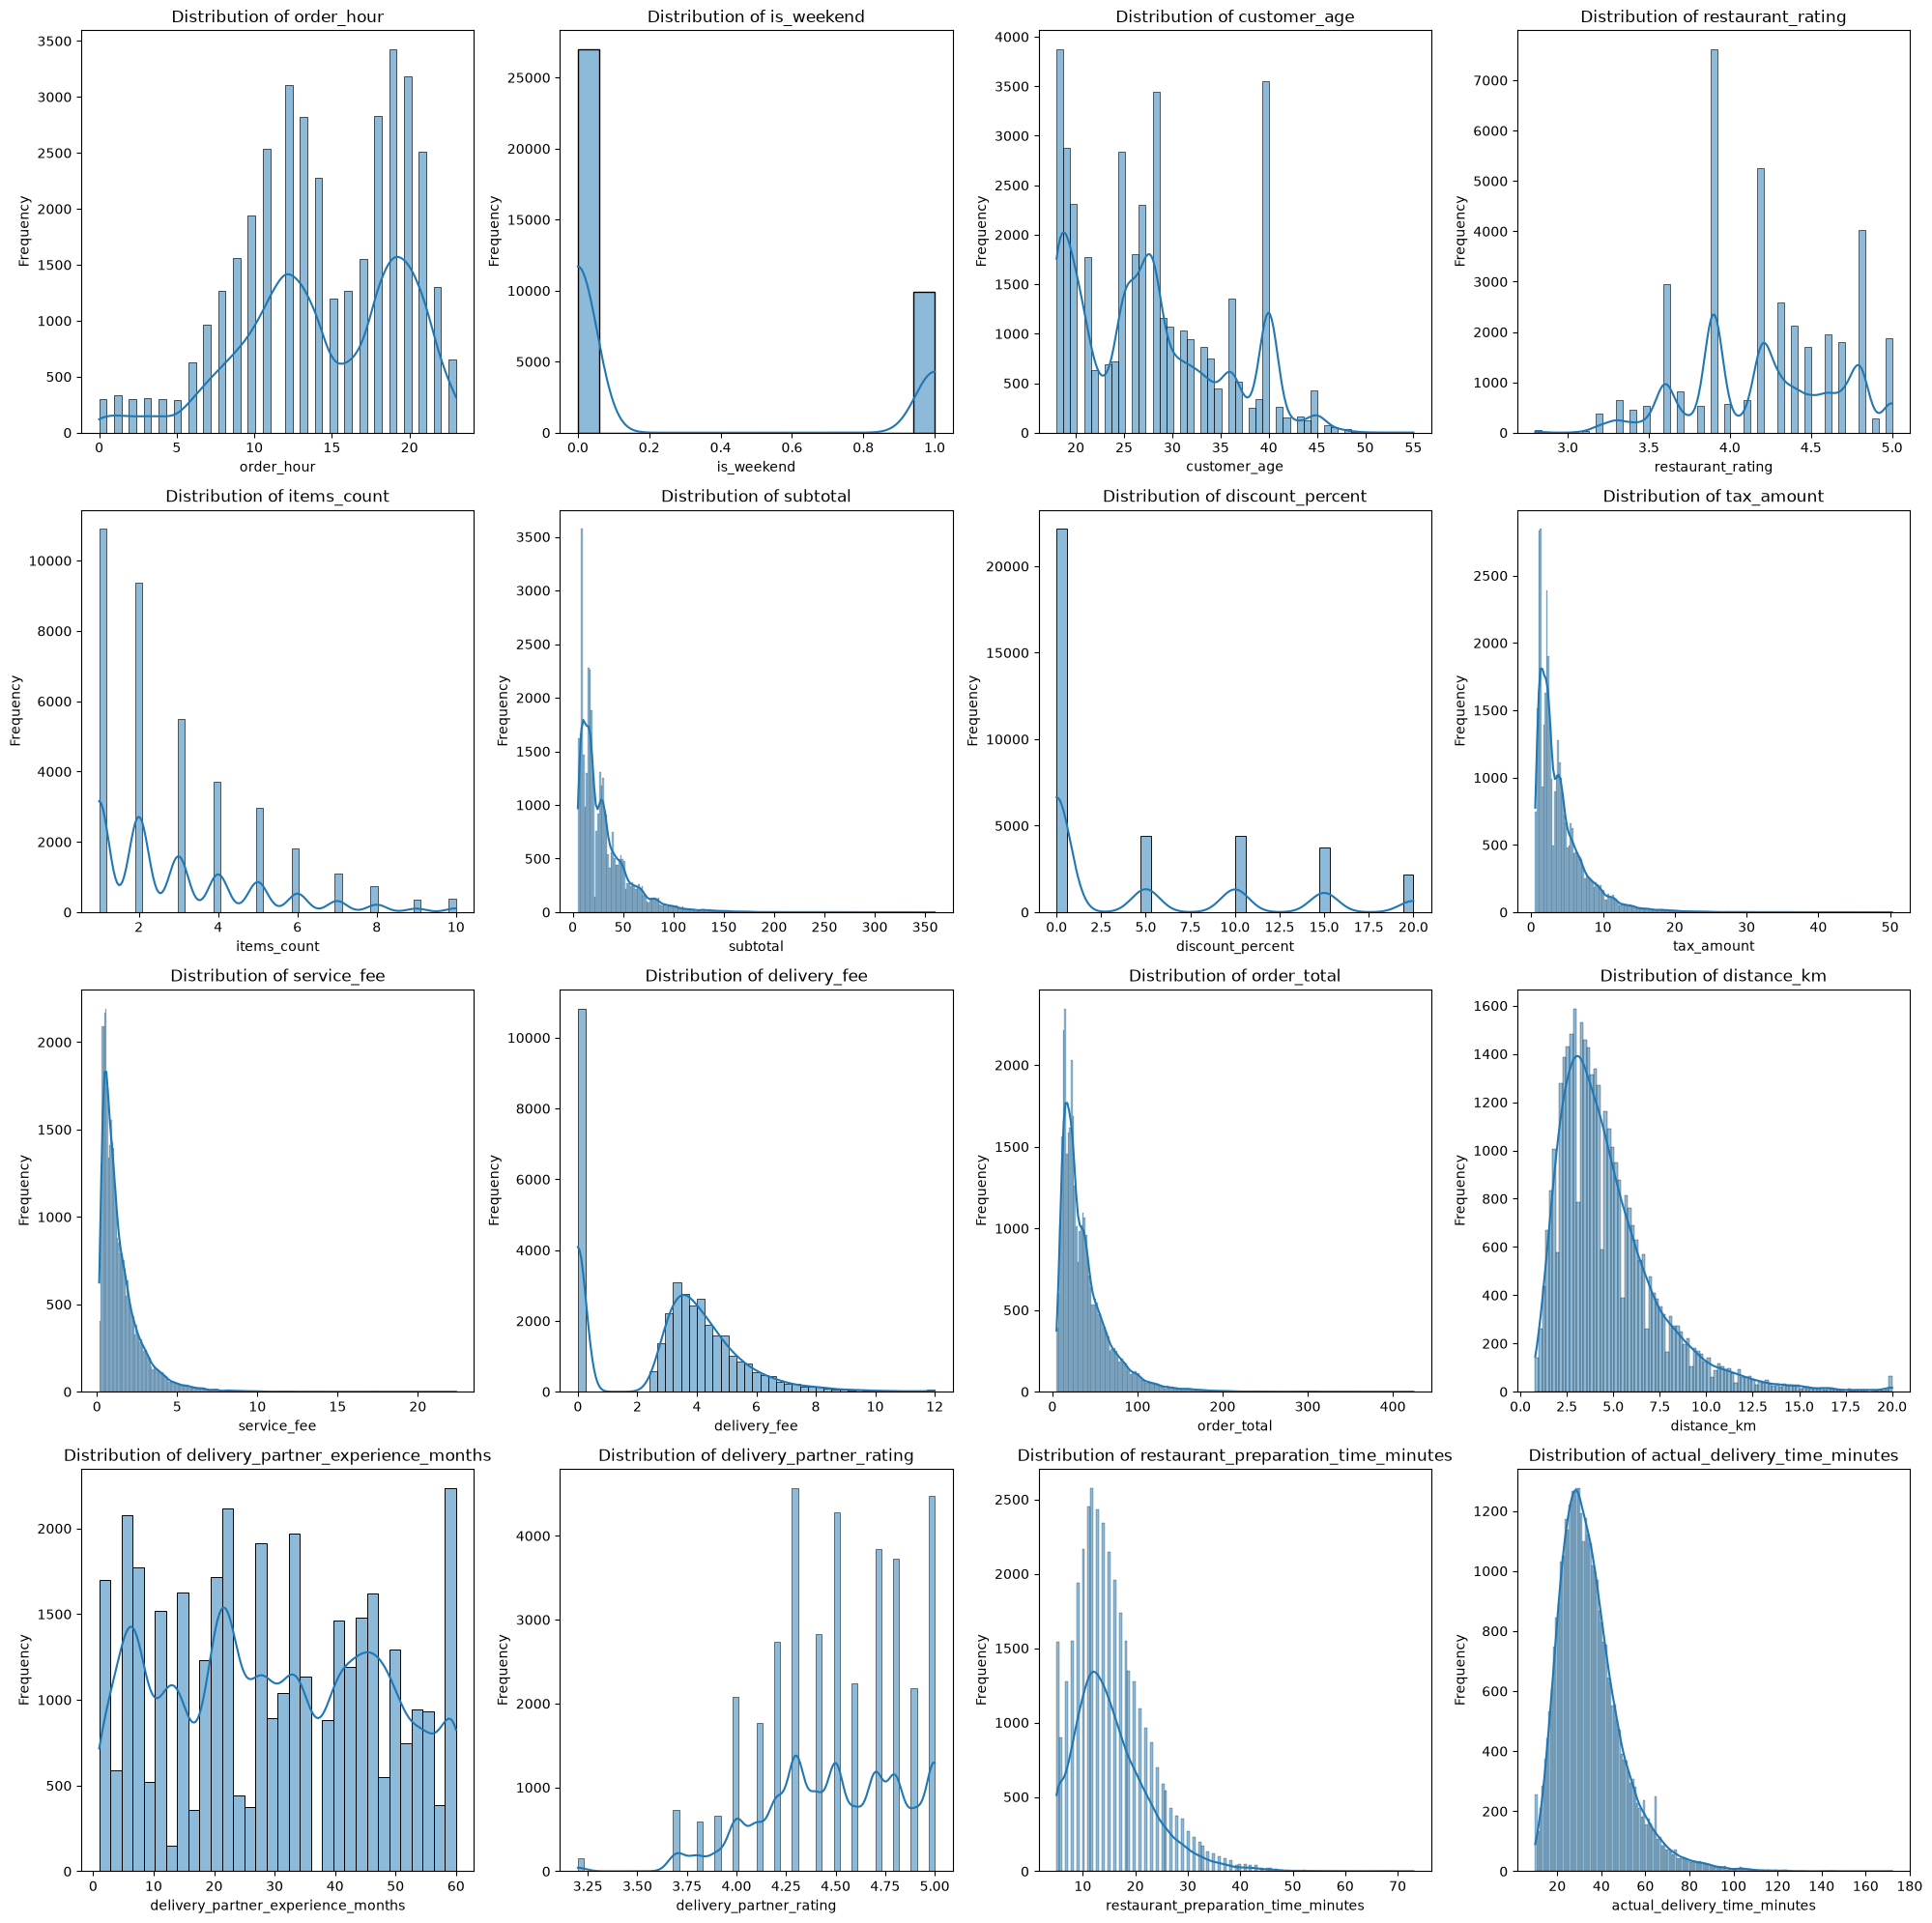

In [20]:

# Number of plots per row
plots_per_row = 4

# Calculate number of rows
num_rows = math.ceil(len(numerical_cols) / plots_per_row)

# Create figure
fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=plots_per_row,
    figsize=(20, 5 * num_rows)
)

# Flatten axes array
axes = axes.flatten()

# Plot histogram for each numerical feature
for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df_train,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove unused subplots
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

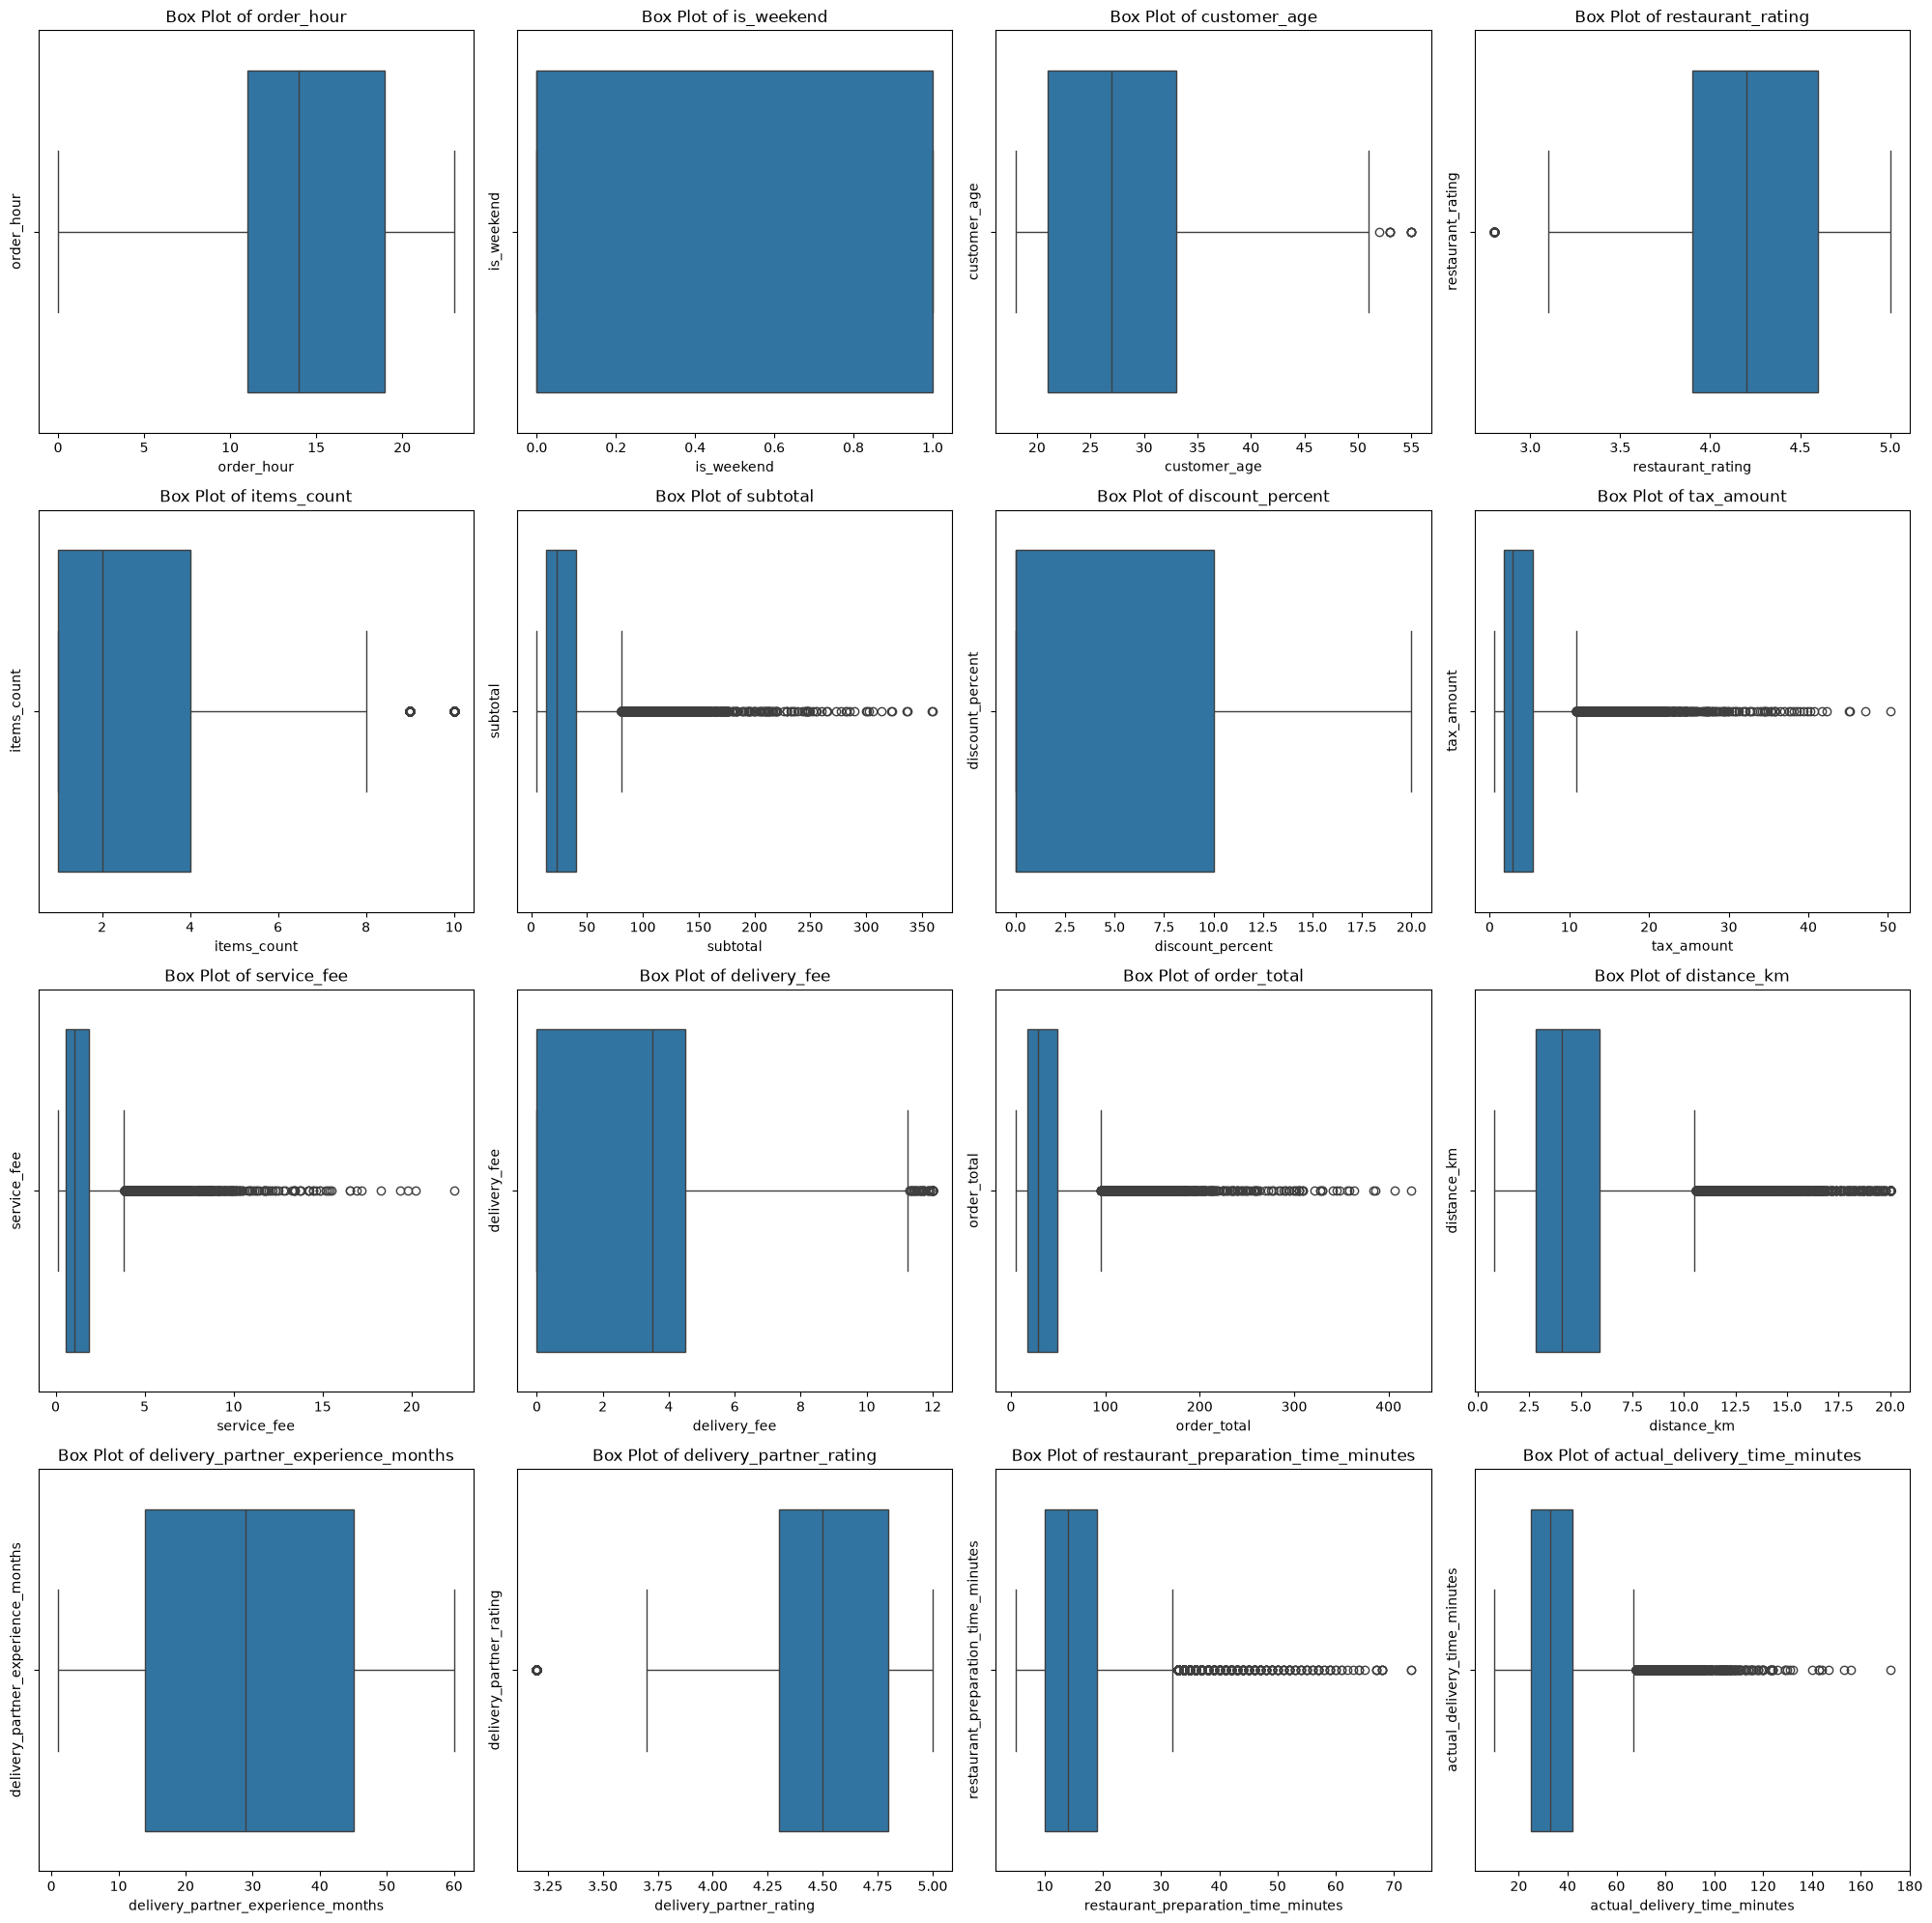

In [21]:
# Number of plots per row
plots_per_row = 4

# Calculate number of rows
num_rows = math.ceil(len(numerical_cols) / plots_per_row)

# Create subplots
fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=plots_per_row,
    figsize=(20, 5 * num_rows)
)

# Flatten axes
axes = axes.flatten()

# Plot box plot for each numerical feature
for i, col in enumerate(numerical_cols):

    sns.boxplot(
        data=df_train,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

# Remove unused subplots
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [22]:
df_train.describe()

,order_hour,is_weekend,customer_age,restaurant_rating,items_count,subtotal,discount_percent,tax_amount,service_fee,delivery_fee,order_total,distance_km,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,actual_delivery_time_minutes
count,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000
mean,14.461451,0.268081,27.659677,4.208174,2.913976,30.903769,4.481580,4.130440,1.475309,3.086017,38.194500,4.737415,29.811378,4.496199,15.542401,35.229966
std,5.229210,0.442966,7.520190,0.451049,2.031655,26.976192,6.407449,3.621813,1.373776,2.307304,30.930321,2.796843,17.424666,0.349111,7.342492,14.791210
min,0.000000,0.000000,18.000000,2.800000,1.000000,5.100000,0.000000,0.570000,0.140000,0.000000,4.900000,0.800000,1.000000,3.200000,5.000000,10.000000
25%,11.000000,0.000000,21.000000,3.900000,1.000000,13.130000,0.000000,1.740000,0.580000,0.000000,17.480000,2.800000,14.000000,4.300000,10.000000,25.000000
50%,14.000000,0.000000,27.000000,4.200000,2.000000,22.960000,0.000000,2.900000,1.050000,3.500000,28.410000,4.100000,29.000000,4.500000,14.000000,33.000000
75%,19.000000,1.000000,33.000000,4.600000,4.000000,40.140000,10.000000,5.390000,1.890000,4.500000,48.730000,5.900000,45.000000,4.800000,19.000000,42.000000
max,23.000000,1.000000,55.000000,5.000000,10.000000,359.590000,20.000000,50.270000,22.380000,12.000000,424.200000,20.000000,60.000000,5.000000,73.000000,172.000000


In [23]:
df_train[df['actual_delivery_time_minutes'] >= 67.5]['traffic_level'].value_counts()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11292\1637261432.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_train[df['actual_delivery_time_minutes'] >= 67.5]['traffic_level'].value_counts()


traffic_level
High      725
Medium    433
Low       125
Name: count, dtype: int64

In [24]:
for col in categorical_cols:
    print(col, df_train[col].value_counts())

day_of_week day_of_week
Thursday     6195
Wednesday    6043
Tuesday      4963
Saturday     4946
Sunday       4936
Monday       4931
Friday       4848
Name: count, dtype: int64
city city
City_A    14637
City_B    10980
City_C     7484
City_D     3761
Name: count, dtype: int64
delivery_area delivery_area
City_A_Area_9     1504
City_A_Area_5     1502
City_A_Area_1     1500
City_A_Area_7     1493
City_A_Area_2     1475
City_A_Area_8     1458
City_A_Area_3     1452
City_A_Area_6     1425
City_A_Area_4     1422
City_A_Area_10    1406
City_B_Area_3     1175
City_B_Area_4     1114
City_B_Area_6     1113
City_B_Area_8     1106
City_B_Area_2     1097
City_B_Area_7     1089
City_B_Area_9     1079
City_B_Area_1     1076
City_B_Area_10    1069
City_B_Area_5     1062
City_C_Area_5      787
City_C_Area_4      777
City_C_Area_9      768
City_C_Area_8      751
City_C_Area_6      745
City_C_Area_3      740
City_C_Area_2      739
City_C_Area_10     728
City_C_Area_1      728
City_C_Area_7      721
City_D

#### Bi-Variate Analysis

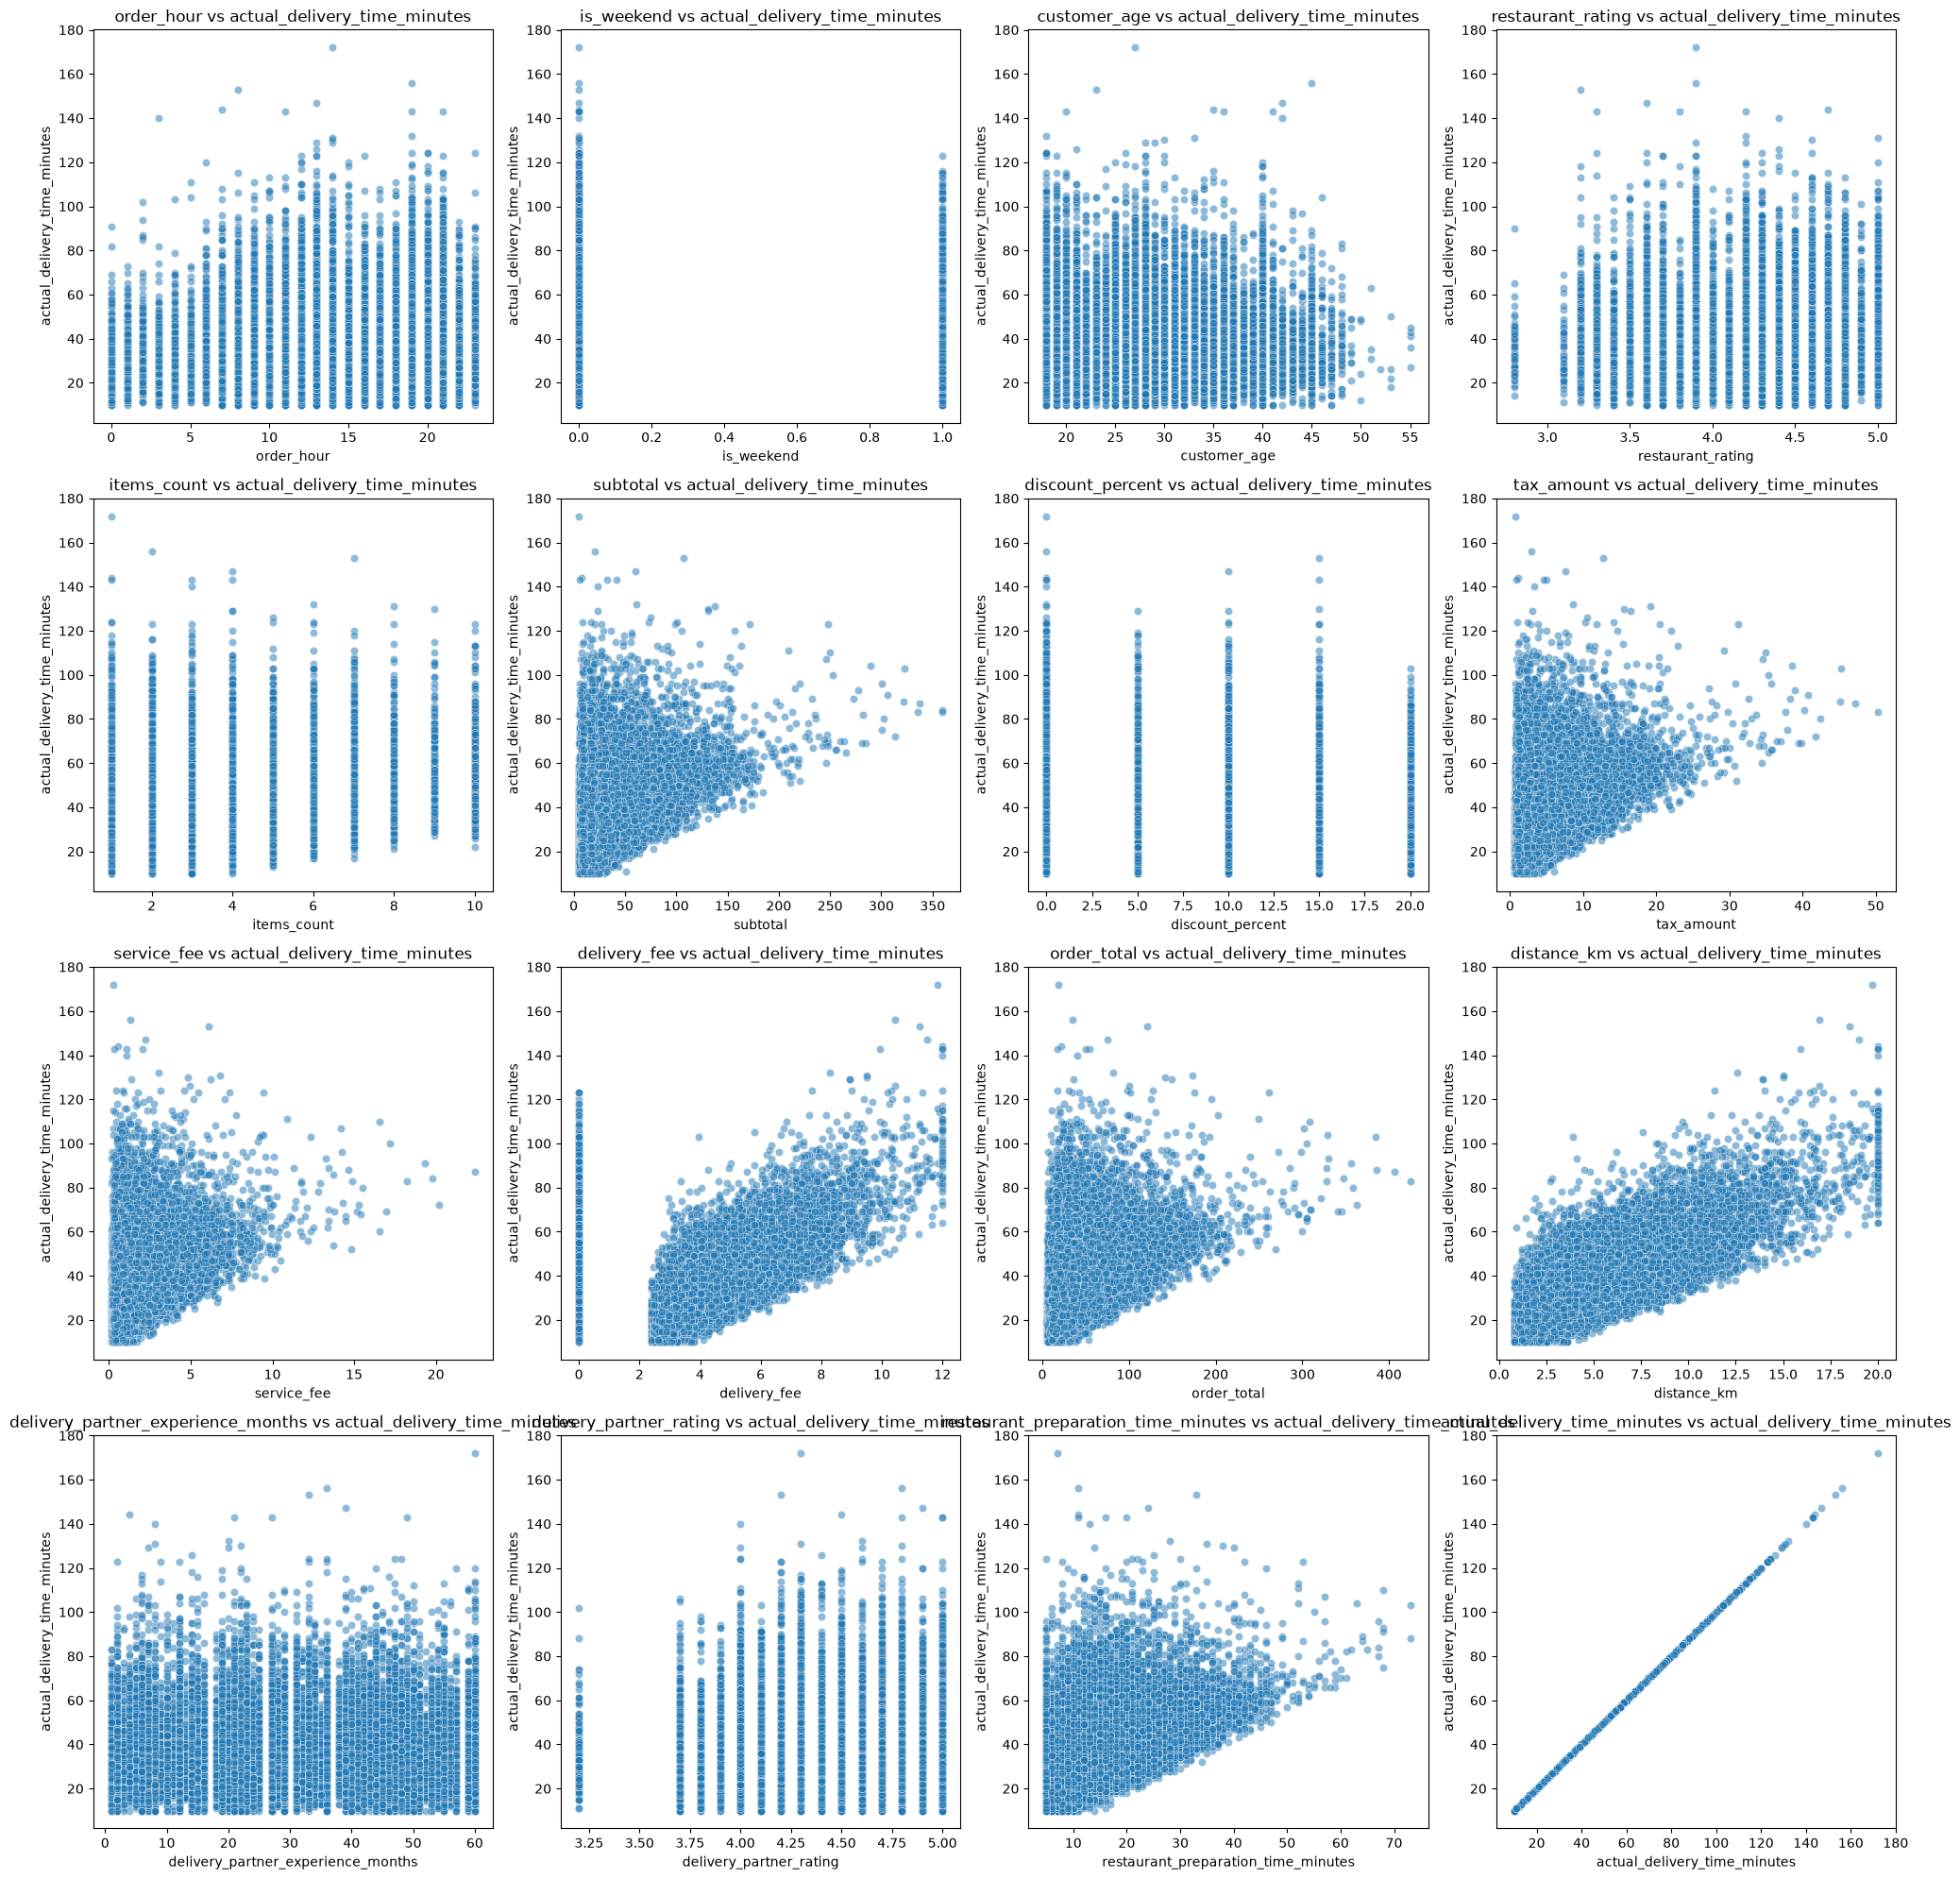

In [25]:
# Target variable
target = 'actual_delivery_time_minutes'

# Number of plots per row
plots_per_row = 4

# Calculate number of rows
num_rows = math.ceil(len(numerical_cols) / plots_per_row)

# Create figure
fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=plots_per_row,
    figsize=(20, 5 * num_rows)
)

# Flatten axes
axes = axes.flatten()

# Create scatter plot for every numerical feature
for i, col in enumerate(numerical_cols):

    sns.scatterplot(
        data=df_train,
        x=col,
        y=target,
        ax=axes[i],
        alpha=0.5
    )

    axes[i].set_title(f'{col} vs {target}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

# Remove unused plots
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### Feature Engineering and Feature Selection

In [26]:
# Does delivery_area explain variance in delivery time beyond city + distance + traffic?
df_train.groupby('delivery_area')['actual_delivery_time_minutes'].mean().sort_values()

delivery_area
City_C_Area_5     33.287166
City_C_Area_6     33.665772
City_C_Area_3     33.737838
City_C_Area_9     33.786458
City_C_Area_4     34.019305
City_C_Area_8     34.095872
City_C_Area_10    34.232143
City_C_Area_2     34.414073
City_A_Area_9     34.543883
City_C_Area_7     34.572816
City_D_Area_1     34.580381
City_D_Area_9     34.642276
City_D_Area_10    34.800000
City_A_Area_4     34.802391
City_C_Area_1     34.854396
City_D_Area_4     34.858667
City_A_Area_3     34.986915
City_A_Area_7     35.020764
City_A_Area_2     35.044068
City_A_Area_1     35.074667
City_A_Area_8     35.234568
City_A_Area_6     35.340351
City_A_Area_10    35.344239
City_B_Area_7     35.391185
City_D_Area_5     35.432877
City_D_Area_2     35.534574
City_A_Area_5     35.648469
City_D_Area_7     35.650273
City_D_Area_6     35.757412
City_B_Area_9     35.812790
City_D_Area_3     35.839599
City_B_Area_5     35.872881
City_B_Area_4     35.907540
City_B_Area_2     36.010027
City_B_Area_1     36.045539
City_D

In [27]:
# Does area effect persist after accounting for distance?
df_train.groupby('delivery_area')['distance_km'].mean().sort_values()

delivery_area
City_D_Area_9     4.476694
City_B_Area_7     4.556198
City_D_Area_1     4.558583
City_B_Area_2     4.619690
City_C_Area_9     4.620443
City_D_Area_5     4.625479
City_B_Area_6     4.637466
City_A_Area_4     4.638748
City_A_Area_2     4.651661
City_D_Area_4     4.660000
City_C_Area_5     4.660991
City_C_Area_3     4.680270
City_C_Area_10    4.686951
City_A_Area_9     4.688564
City_D_Area_10    4.698205
City_C_Area_6     4.700000
City_B_Area_9     4.713531
City_A_Area_1     4.722600
City_D_Area_3     4.732331
City_A_Area_7     4.734226
City_A_Area_3     4.739187
City_B_Area_1     4.742193
City_A_Area_10    4.749929
City_D_Area_7     4.768579
City_B_Area_4     4.773429
City_A_Area_6     4.776281
City_C_Area_8     4.780959
City_D_Area_6     4.782480
City_B_Area_10    4.792703
City_B_Area_5     4.795009
City_B_Area_3     4.795574
City_D_Area_2     4.796543
City_C_Area_4     4.799743
City_C_Area_2     4.801218
City_D_Area_8     4.817232
City_A_Area_8     4.822085
City_C_Area_1 

delivery_area was evaluated for incremental signal over city/distance/traffic/weather; area-level averages showed a spread of ~4 minutes with no significant correlation to area-level distance (r=0.32, p=0.10), suggesting the variation is largely noise. Dropped to reduce dimensionality from one-hot/target encoding of 40 categories.

In [28]:
df.groupby('day_of_week')['actual_delivery_time_minutes'].mean()

day_of_week
Friday       34.619610
Monday       36.633945
Saturday     34.551782
Sunday       33.762813
Thursday     35.351251
Tuesday      35.147149
Wednesday    35.802484
Name: actual_delivery_time_minutes, dtype: float64

dropped is_weekend in favor of day_of_week, which showed statistically significant variation (spread ≈17x SE) that is_weekend couldn't capture — notably Monday being the slowest day and Saturday behaving unlike Sunday despite both being "weekend."

In [29]:
# Removing unique id columns, order_timestamp
df_train.drop(['order_id', 'order_date', 'is_weekend', 'customer_id', 'restaurant_id', 'driver_id', 'order_timestamp', 'delivery_area'], axis=1, inplace=True)
df_test.drop(['order_id', 'order_date', 'is_weekend', 'customer_id', 'restaurant_id', 'driver_id', 'order_timestamp', 'delivery_area'], axis=1, inplace=True)

In [30]:
cols_to_scale = ['order_hour', 'customer_age', 'restaurant_rating', 'items_count',
       'subtotal', 'discount_percent', 'tax_amount', 'service_fee',
       'delivery_fee', 'order_total', 'distance_km',
       'delivery_partner_experience_months', 'delivery_partner_rating',
       'restaurant_preparation_time_minutes']

In [31]:
encoding_cols = ['day_of_week', 'city', 'customer_type', 'restaurant_type',
       'restaurant_primary_category', 'payment_method', 'weather',
       'traffic_level']

In [32]:
X_train = df_train.drop('actual_delivery_time_minutes', axis=1)
y_train = df_train['actual_delivery_time_minutes']

X_test = df_test.drop('actual_delivery_time_minutes', axis=1)
y_test = df_test['actual_delivery_time_minutes']

#### Using One-Hot Encoding for categorical cols

In [33]:
X_train_1 = pd.get_dummies(X_train, columns=encoding_cols, drop_first=True, dtype='float64')
X_test_1 = pd.get_dummies(X_test, columns=encoding_cols, drop_first=True, dtype='float64')

#### Scaling using Min Max Scalar

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_1[cols_to_scale] = scaler.fit_transform(X_train_1[cols_to_scale])
X_test_1[cols_to_scale] = scaler.transform(X_test_1[cols_to_scale])

In [35]:
X_train_1.columns


Index(['order_hour', 'customer_age', 'restaurant_rating', 'items_count',
       'subtotal', 'discount_percent', 'tax_amount', 'service_fee',
       'delivery_fee', 'order_total', 'distance_km',
       'delivery_partner_experience_months', 'delivery_partner_rating',
       'restaurant_preparation_time_minutes', 'day_of_week_Monday',
       'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday',
       'day_of_week_Tuesday', 'day_of_week_Wednesday', 'city_City_B',
       'city_City_C', 'city_City_D', 'customer_type_Premium',
       'customer_type_Regular', 'restaurant_type_Casual Dining',
       'restaurant_type_Fast Food', 'restaurant_type_Fine Dining',
       'restaurant_primary_category_Burger',
       'restaurant_primary_category_Dessert',
       'restaurant_primary_category_Healthy',
       'restaurant_primary_category_Local',
       'restaurant_primary_category_Pizza', 'payment_method_Credit Card',
       'payment_method_Digital Wallet', 'weather_Cloudy', 'weather_Rai

In [36]:
len(X_train_1.columns), len(X_test_1.columns)

(40, 40)

In [37]:
X_train_1.describe()

,order_hour,customer_age,restaurant_rating,items_count,subtotal,discount_percent,tax_amount,service_fee,delivery_fee,order_total,...,restaurant_primary_category_Healthy,restaurant_primary_category_Local,restaurant_primary_category_Pizza,payment_method_Credit Card,payment_method_Digital Wallet,weather_Cloudy,weather_Rain,weather_Storm,traffic_level_Low,traffic_level_Medium
count,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000,...,36862.000000,36862.000000,36862.000000,36862.000000,36862.00000,36862.000000,36862.000000,36862.000000,36862.000000,36862.000000
mean,0.628759,0.261072,0.640079,0.212664,0.072791,0.224079,0.071639,0.060041,0.257168,0.079405,...,0.072731,0.254083,0.081412,0.497721,0.19885,0.257203,0.152216,0.026097,0.304243,0.389778
std,0.227357,0.203248,0.205022,0.225739,0.076099,0.320372,0.072874,0.061770,0.192275,0.073767,...,0.259698,0.435350,0.273470,0.500002,0.39914,0.437098,0.359235,0.159427,0.460092,0.487706
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.478261,0.081081,0.500000,0.000000,0.022652,0.000000,0.023541,0.019784,0.000000,0.030002,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.608696,0.243243,0.636364,0.111111,0.050382,0.000000,0.046881,0.040917,0.291667,0.056070,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.826087,0.405405,0.818182,0.333333,0.098846,0.500000,0.096982,0.078687,0.375000,0.104531,...,0.000000,1.000000,0.000000,1.000000,0.00000,1.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


Using VIF on Numerical Features

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

    return vif_df

vif_df = calculate_vif(X_train_1)
vif_df['VIF'] = vif_df['VIF'].round(2)
vif_df

,Columns,VIF
0,order_hour,8.62
1,customer_age,3.15
2,restaurant_rating,13.24
3,items_count,11.98
4,subtotal,427.86
5,discount_percent,3.41
6,tax_amount,3056355.26
7,service_fee,6592.84
8,delivery_fee,26177.00
9,order_total,3697676.34


In [39]:
calculate_vif(X_train_1.drop(['subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee'], axis=1))

,Columns,VIF
0,order_hour,8.126426
1,customer_age,3.137255
2,restaurant_rating,12.236884
3,items_count,11.444348
4,order_total,17.457914
5,distance_km,2.932700
6,delivery_partner_experience_months,3.679024
7,delivery_partner_rating,12.486468
8,restaurant_preparation_time_minutes,13.567481
9,day_of_week_Monday,2.114760


dropped fetaures based on VIF 

In [40]:
X_train_1 = X_train_1.drop(['subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee'], axis=1).copy()
X_test_1 = X_test_1.drop(['subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee'], axis=1).copy()

In [41]:
suspect_cols = ['order_total', 'items_count', 'restaurant_rating', 
                'delivery_partner_rating', 'restaurant_preparation_time_minutes']
X_train_1[suspect_cols].corr()

,order_total,items_count,restaurant_rating,delivery_partner_rating,restaurant_preparation_time_minutes
order_total,1.000000,0.787518,0.042769,-0.008021,0.861754
items_count,0.787518,1.000000,-0.008090,-0.004860,0.745466
restaurant_rating,0.042769,-0.008090,1.000000,0.017481,0.049411
delivery_partner_rating,-0.008021,-0.004860,0.017481,1.000000,-0.003235
restaurant_preparation_time_minutes,0.861754,0.745466,0.049411,-0.003235,1.000000


#### Model Training and Evaluation

1. Linear Regression Model

In [42]:
model_lr = LinearRegression()
model_lr.fit(X_train_1, y_train)

y_pred_lr = model_lr.predict(X_test_1)

performance_dict = {
    "Linear Regression": {
        "Training Score": model_lr.score(X_train_1, y_train),
        "Test Score": model_lr.score(X_test_1, y_test),
        "R2-Score": r2_score(y_test, y_pred_lr),
        "MSE": mean_squared_error(y_test, y_pred_lr),
        "MAE": mean_absolute_error(y_test, y_pred_lr)
    }
}

print("Model Perfomance Report: Linear Regression \n")
print(performance_dict)

Model Perfomance Report: Linear Regression 

{'Linear Regression': {'Training Score': 0.9347426455544218, 'Test Score': 0.9345731274459329, 'R2-Score': 0.9345731274459329, 'MSE': 13.61354032894987, 'MAE': 2.761406615517387}}


In [43]:
def plot_feature_importance(cols, coef):
    coef_df = pd.DataFrame({
    'feature': cols,   
    'coefficient': coef
    }).sort_values('coefficient', ascending=True)

    # Plot
    plt.figure(figsize=(10, len(coef_df) * 0.3))
    colors = ['#d62728' if c < 0 else '#2ca02c' for c in coef_df['coefficient']]

    plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient Value')
    plt.title('Linear Regression Coefficients')
    plt.tight_layout()
    plt.show()

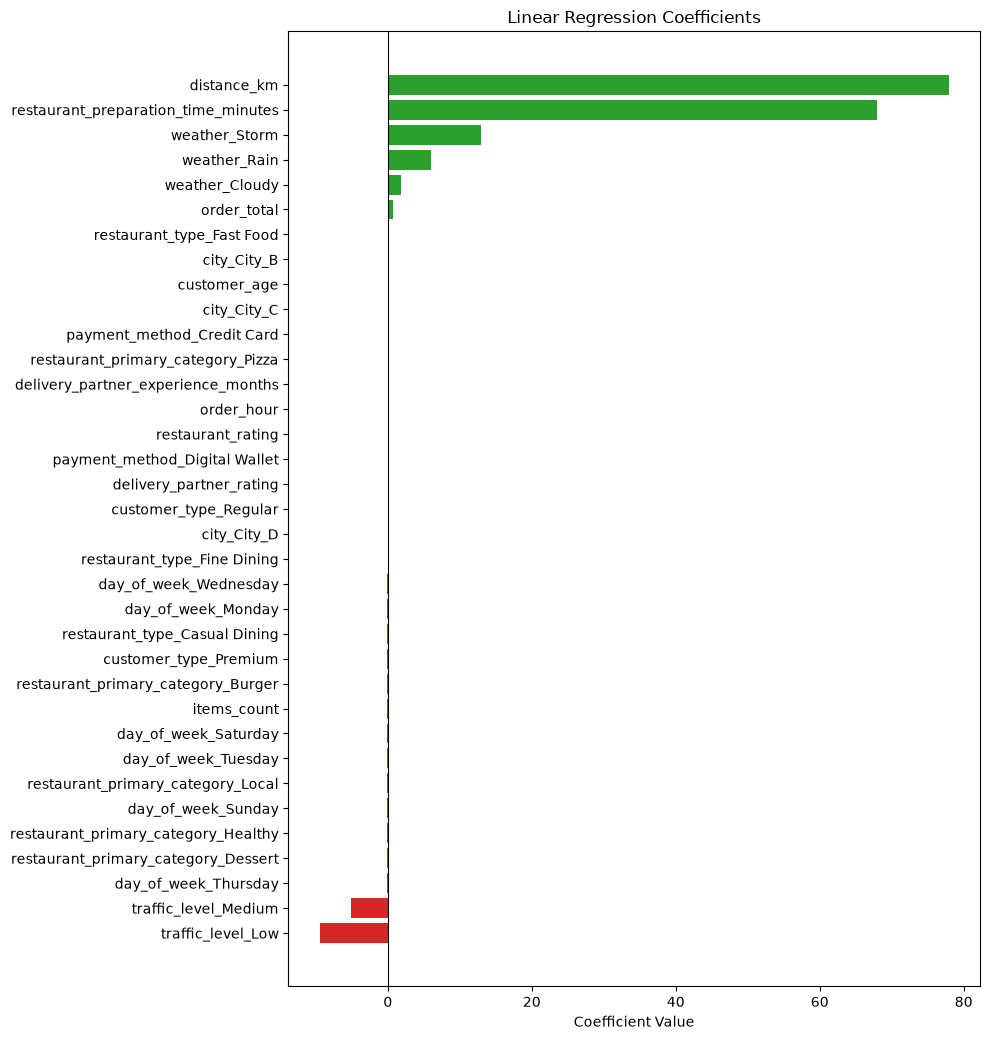

In [44]:
plot_feature_importance(X_train_1.columns, model_lr.coef_)

2. RandomForest Regressor

In [45]:
rfc_model = RandomForestRegressor(random_state=42)
rfc_model.fit(X_train_1, y_train)

y_pred_rfc = rfc_model.predict(X_test_1)

performance_dict = {
    "Random Forest Regression": {
        "Training Score": rfc_model.score(X_train_1, y_train),
        "Test Score": rfc_model.score(X_test_1, y_test),
        "R2-Score": r2_score(y_test, y_pred_rfc),
        "MSE": mean_squared_error(y_test, y_pred_rfc),
        "MAE": mean_absolute_error(y_test, y_pred_rfc)
    }
}

print("Model Perfomance Report: Random Forest Regression \n")
print(performance_dict)

Model Perfomance Report: Random Forest Regression 

{'Random Forest Regression': {'Training Score': 0.9945579034707401, 'Test Score': 0.9601819789103632, 'R2-Score': 0.9601819789103632, 'MSE': 8.285039690301549, 'MAE': 2.2496169519152405}}


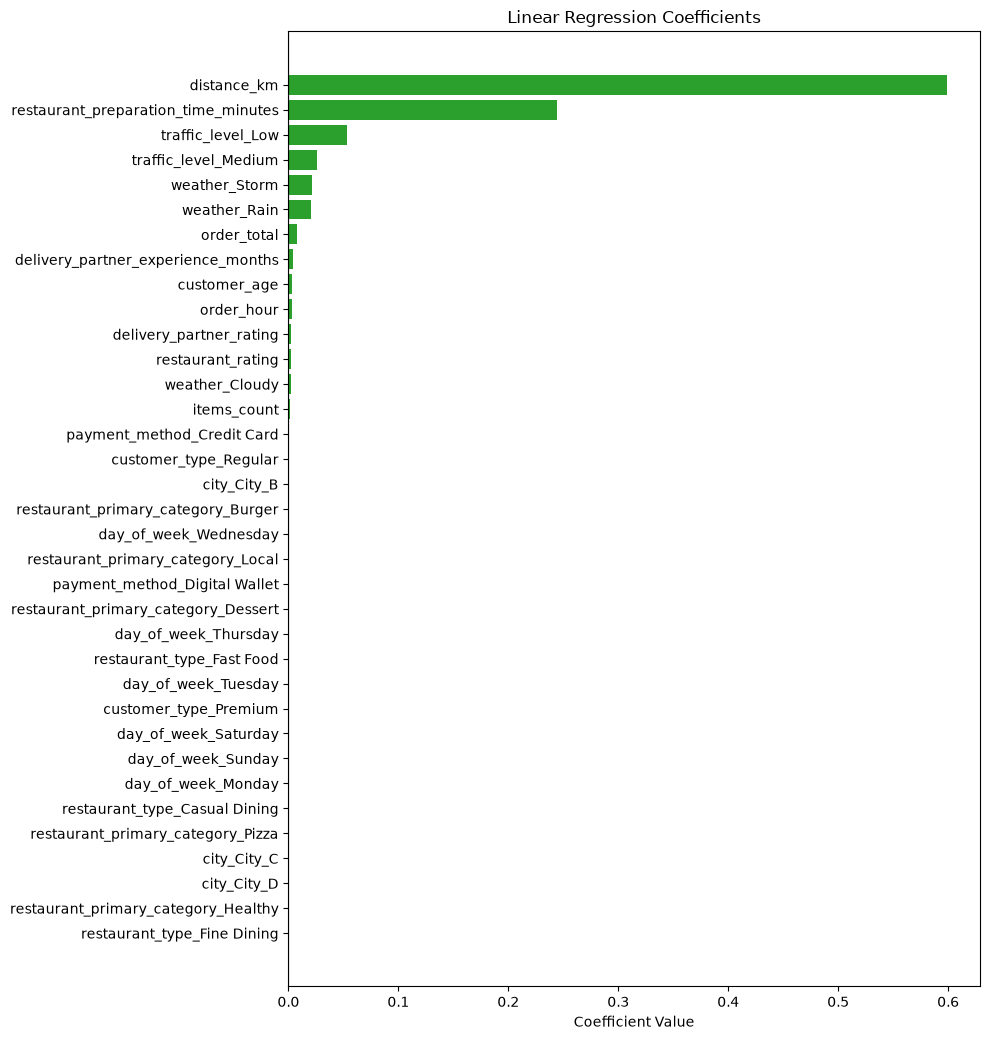

In [46]:
plot_feature_importance(X_train_1.columns, rfc_model.feature_importances_)

3. XGBRegressor

In [47]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_1, y_train)

y_pred_xgb = xgb_model.predict(X_test_1)

performance_dict = {
    "XGBoost Regression": {
        "Training Score": xgb_model.score(X_train_1, y_train),
        "Test Score": xgb_model.score(X_test_1, y_test),
        "R2-Score": r2_score(y_test, y_pred_xgb),
        "MSE": mean_squared_error(y_test, y_pred_xgb),
        "MAE": mean_absolute_error(y_test, y_pred_xgb)
    }
}

print("Model Perfomance Report: XGBoost Regression \n")
print(performance_dict)

Model Perfomance Report: XGBoost Regression 

{'XGBoost Regression': {'Training Score': 0.9765514003077043, 'Test Score': 0.9641064240117514, 'R2-Score': 0.9641064240117514, 'MSE': 7.468470143708159, 'MAE': 2.1754608873244505}}


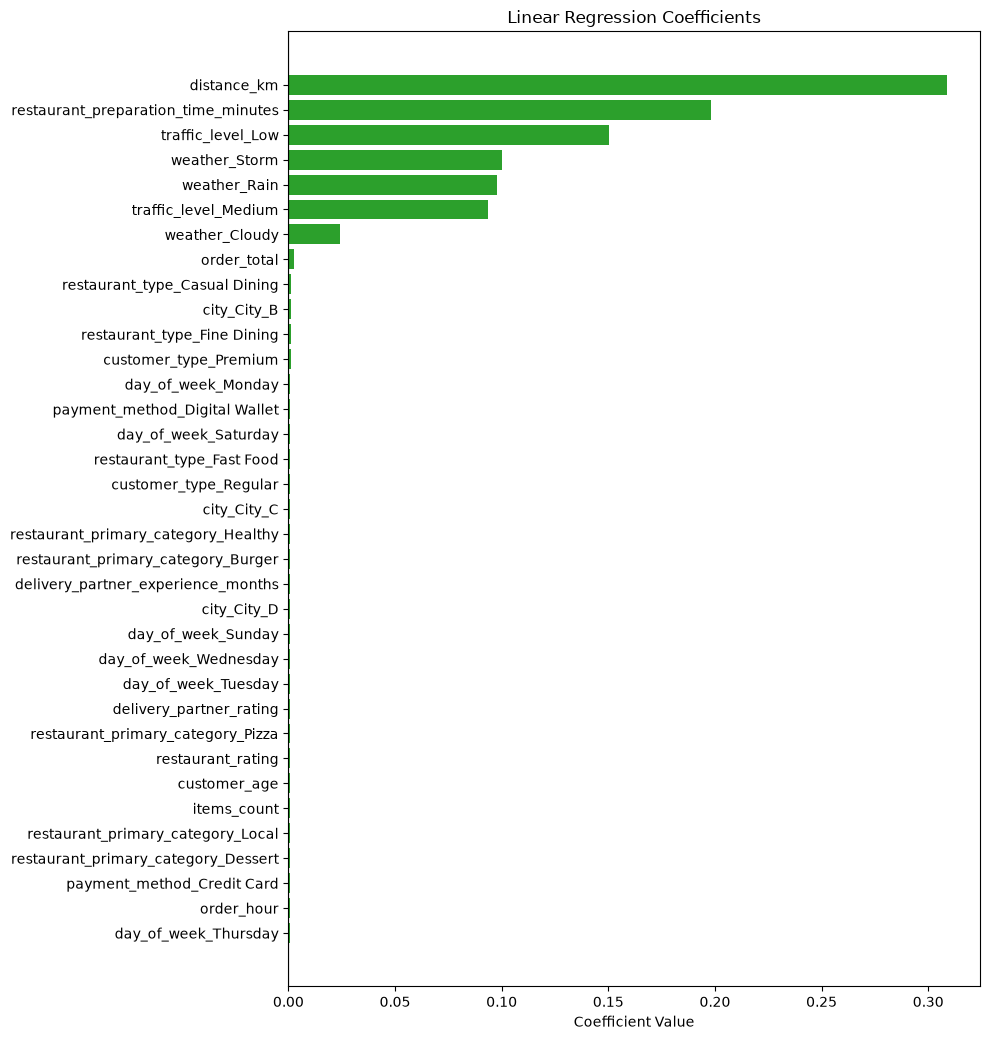

In [48]:
plot_feature_importance(X_train_1.columns, xgb_model.feature_importances_)

#### Hyper Parameter Tuning using Randomized Search CV on XGBRegressor

In [49]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

# Parameter search space
params = {
    "n_estimators": randint(30, 100),
    "learning_rate": uniform(0.02, 0.18),      # 0.02 - 0.20
    "max_depth": randint(3, 9),
    "min_child_weight": randint(1, 8),
    "gamma": uniform(0, 2),
    "subsample": uniform(0.7, 0.3),            # 0.7 - 1.0
    "colsample_bytree": uniform(0.7, 0.3),     # 0.7 - 1.0
    "reg_alpha": uniform(0, 0.5),
    "reg_lambda": uniform(1, 4)
}

# XGBoost Regressor
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,                         # Only 20 combinations
    scoring="r2",
    cv=3,                              # 3-fold CV
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit
random_search.fit(X_train_1, y_train)

# Results
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV R2-Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'colsample_bytree': np.float64(0.7913841307520112), 'gamma': np.float64(0.19534422801276774), 'learning_rate': np.float64(0.14316194477218824), 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 73, 'reg_alpha': np.float64(0.2475884550556351), 'reg_lambda': np.float64(1.1375540844608736), 'subsample': np.float64(0.9727961206236346)}

Best CV R2-Score:
0.967144455758915


Selecting Best Estimator based on results of RandomizedSearchCV

In [50]:
best_model = random_search.best_estimator_

best_model.fit(X_train_1, y_train)
y_pred_best = best_model.predict(X_test_1)

performance_dict = {
    "XGBoost Regression": {
        "Training Score": best_model.score(X_train_1, y_train),
        "Test Score": best_model.score(X_test_1, y_test),
        "R2-Score": r2_score(y_test, y_pred_best),
        "MSE": mean_squared_error(y_test, y_pred_best),
        "MAE": mean_absolute_error(y_test, y_pred_best)
    }
}

print("Model Perfomance Report: Best Params XGBoost Regression \n")
print(performance_dict)

Model Perfomance Report: Best Params XGBoost Regression 

{'XGBoost Regression': {'Training Score': 0.9725129203725077, 'Test Score': 0.9661986546142851, 'R2-Score': 0.9661986546142851, 'MSE': 7.0331342553616985, 'MAE': 2.115352808991971}}


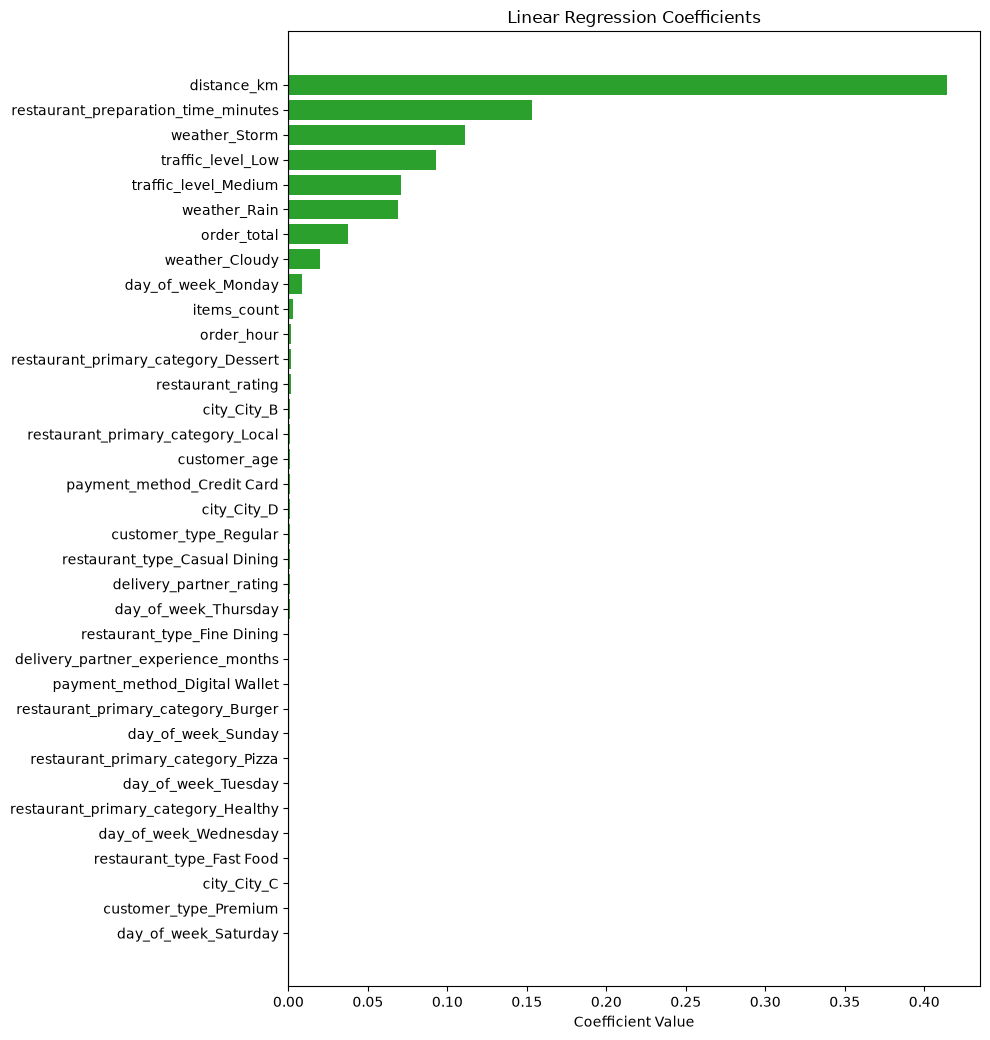

In [51]:
# Plot Features Importance for Best XGB model

plot_feature_importance(X_train_1.columns, best_model.feature_importances_)

#### SHAP Implementation for Model Evaluation of our Best XGBoost Model

In [52]:
import xgboost as xgb

dtest = xgb.DMatrix(X_test_1)

shap_values = best_model.get_booster().predict(dtest, pred_contribs=True)

base_value = shap_values[:, -1]
shap_values = shap_values[:, :-1]

print(shap_values.shape) 

(12270, 35)


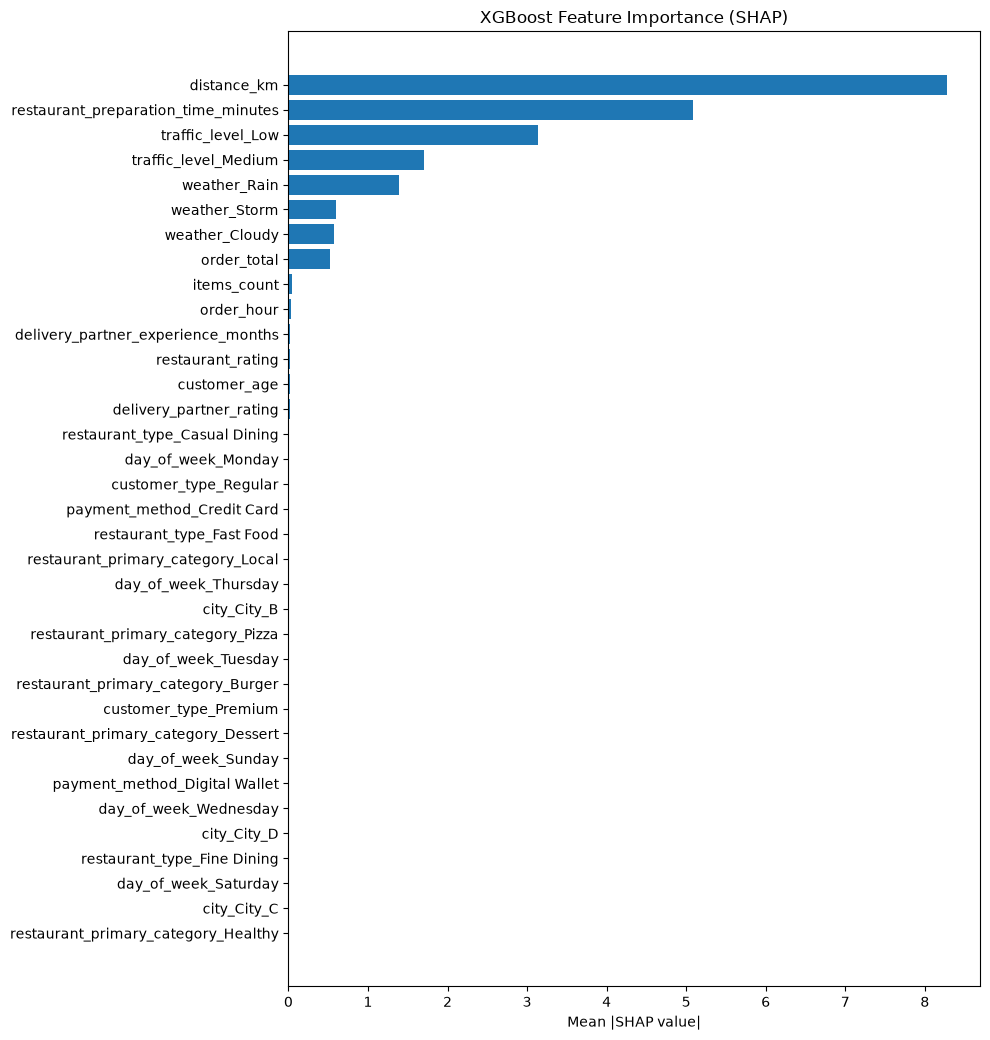

In [53]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_test_1.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

plt.figure(figsize=(10, len(importance_df) * 0.3))
plt.barh(importance_df['feature'], importance_df['mean_abs_shap'], color='#1f77b4')
plt.xlabel('Mean |SHAP value|')
plt.title('XGBoost Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

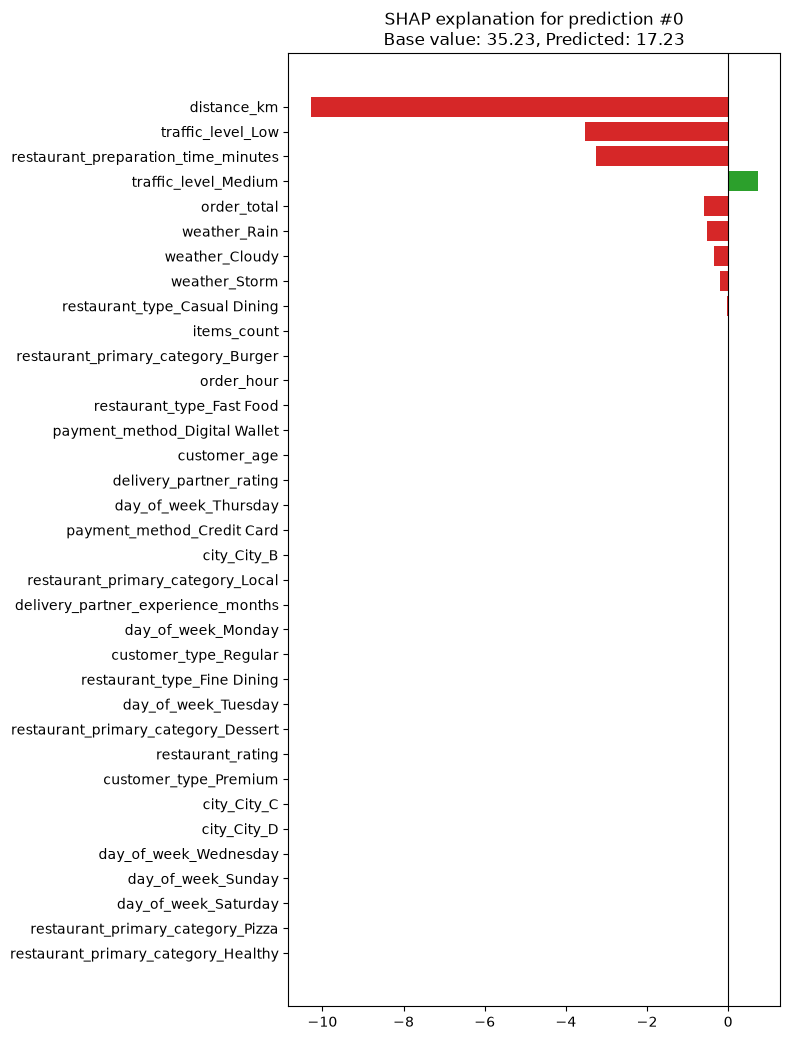

In [54]:
idx = 0  # pick any row
row_shap = pd.DataFrame({
    'feature': X_test_1.columns,
    'shap_value': shap_values[idx]
}).sort_values('shap_value', key=abs, ascending=True)

plt.figure(figsize=(8, len(row_shap) * 0.3))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in row_shap['shap_value']]
plt.barh(row_shap['feature'], row_shap['shap_value'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f"SHAP explanation for prediction #{idx}\nBase value: {base_value[idx]:.2f}, Predicted: {base_value[idx] + shap_values[idx].sum():.2f}")
plt.tight_layout()
plt.show()

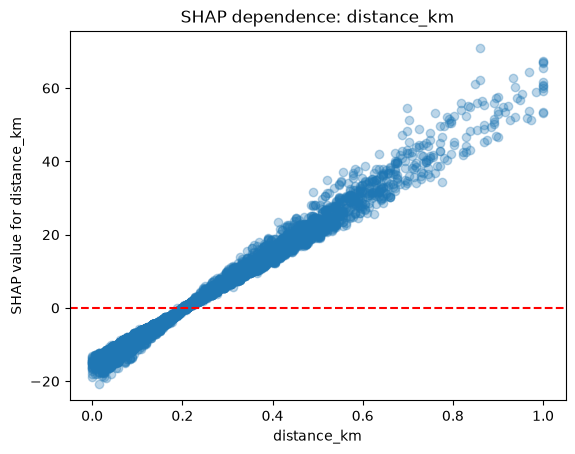

In [55]:
# plt.figure(figsize=(8,5))
plt.scatter(X_test_1['distance_km'], shap_values[:, X_test_1.columns.get_loc('distance_km')], alpha=0.3)
plt.xlabel('distance_km')
plt.ylabel('SHAP value for distance_km')
plt.axhline(0, color='r', linestyle='--')
plt.title('SHAP dependence: distance_km')
plt.show()

#### Error Analysis

In [67]:
# Consolidated error dataframe with original (readable) features attached
df_err = X_test_1.copy().reset_index(drop=True)
df_err['actual'] = y_test.reset_index(drop=True)
df_err['predicted'] = y_pred_best
df_err['error'] = df_err['actual'] - df_err['predicted']          # signed: +ve = under-predicted
df_err['abs_error'] = df_err['error'].abs()
df_err['pct_error'] = (df_err['error'] / df_err['actual']) * 100

print(f"MAE: {df_err['abs_error'].mean():.2f} min")
print(f"Median abs error: {df_err['abs_error'].median():.2f} min")
print(f"90th percentile abs error: {df_err['abs_error'].quantile(0.9):.2f} min")
df_err.head()

MAE: 2.12 min
Median abs error: 1.79 min
90th percentile abs error: 4.34 min


,order_hour,customer_age,restaurant_rating,items_count,order_total,distance_km,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,day_of_week_Monday,...,weather_Cloudy,weather_Rain,weather_Storm,traffic_level_Low,traffic_level_Medium,actual,predicted,error,abs_error,pct_error
0,0.130435,0.270270,0.909091,0.000000,0.027904,0.057292,0.237288,0.833333,0.102941,0.0,...,0.0,0.0,0.0,1.0,0.0,16.0,17.233534,-1.233534,1.233534,-7.709587
1,0.565217,0.243243,0.818182,0.333333,0.146625,0.145833,0.457627,0.611111,0.191176,0.0,...,0.0,0.0,0.0,1.0,0.0,33.0,27.828978,5.171022,5.171022,15.669765
2,0.608696,0.405405,0.727273,0.111111,0.060148,0.359375,0.406780,1.000000,0.073529,0.0,...,1.0,0.0,0.0,0.0,1.0,40.0,41.267735,-1.267735,1.267735,-3.169336
3,0.521739,0.594595,0.272727,0.000000,0.012187,0.109375,0.474576,0.611111,0.073529,0.0,...,1.0,0.0,0.0,0.0,1.0,26.0,22.402580,3.597420,3.597420,13.836230
4,0.391304,0.054054,0.681818,0.222222,0.083162,0.161458,0.084746,0.888889,0.161765,0.0,...,0.0,0.0,0.0,0.0,1.0,31.0,31.348114,-0.348114,0.348114,-1.122948


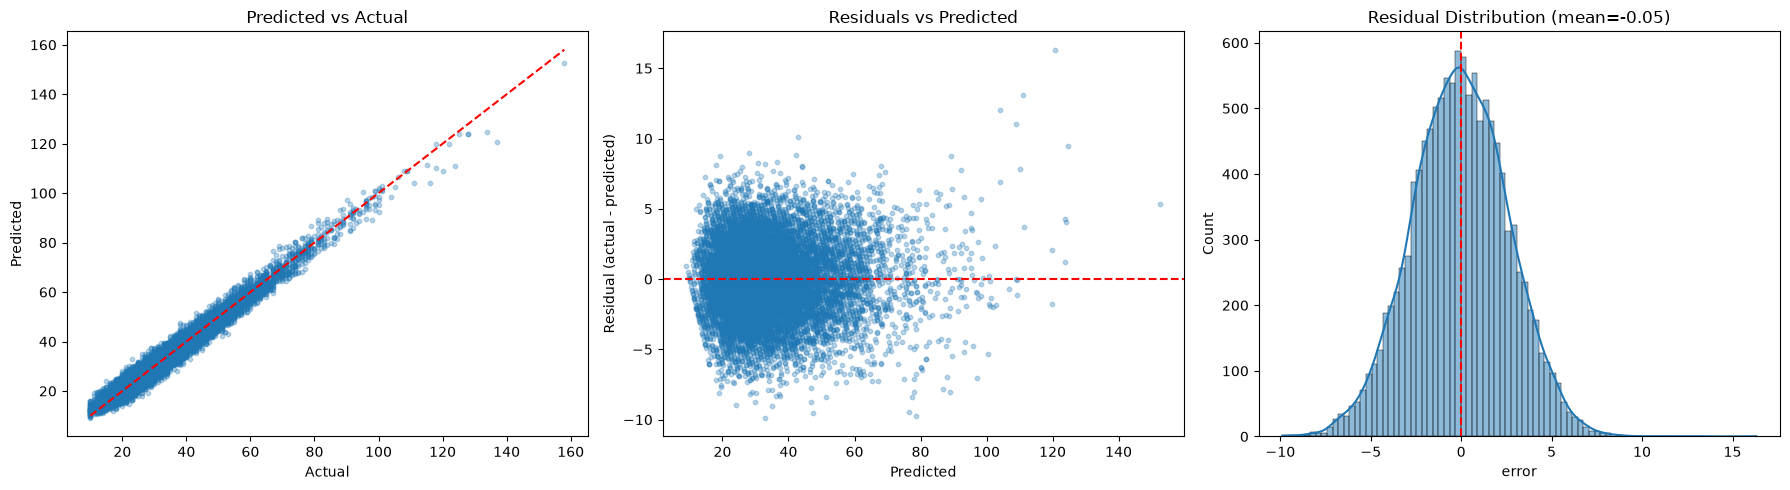

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual
axes[0].scatter(df_err['actual'], df_err['predicted'], alpha=0.3, s=10)
lims = [df_err['actual'].min(), df_err['actual'].max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual')

# Residuals vs Predicted — check for heteroscedasticity / curvature
axes[1].scatter(df_err['predicted'], df_err['error'], alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals vs Predicted')

# Residual distribution — check for skew/bias
sns.histplot(df_err['error'], kde=True, ax=axes[2])
axes[2].axvline(0, color='r', linestyle='--')
axes[2].set_title(f"Residual Distribution (mean={df_err['error'].mean():.2f})")

plt.tight_layout()
plt.show()